# ML Analysis 3.1 — Dividend Initiations & Omissions
*(extended: Top-5 SHAP by period / warning-clean)*

**Thesis:** *When Firms Start and Stop Paying: Machine Learning Evidence on Dividend Initiation and Omission*
**Author:** Matyáš Ležatka · Utrecht University · June 2026

This notebook contains the thesis-facing machine-learning analysis: a six-model rolling-window horse race, out-of-sample XGBoost SHAP interpretation, investor screening, statistical tests, and named case studies.

| Section | Thesis output |
|---|---|
| §5–§6 | Tables 5.3–5.4: walk-forward performance |
| §7 | Table A.1: paired Wilcoxon tests with Bonferroni correction |
| §8 | Figure 5.1: SHAP beeswarm |
| §9 | Table: top-5 XGBoost SHAP predictors by time period |
| §10 | Table 5.5: time-varying winning variables |
| §11–§12 | Table 5.6, Figure 5.3, Table A.2: investor screening |
| §13–§16 | Figures 5.4–5.5, Appendix B.1: local SHAP case studies |

**Design invariants**
- Predictors are the 34 selected `_lag1` columns; same-year variables never enter models.
- Each fold trains on `[t−10, t−1]` and tests on year `t` — no future information leaks into training.
- Imputation, scaling, and class weights are fitted inside each training fold only.
- `F1@top-k` flags the `k` highest-scored observations per fold, where `k` equals the actual event count.

## §1 — Imports & paths


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pathlib
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score, brier_score_loss, f1_score,
)

import xgboost as xgb
import lightgbm as lgb
import shap

print(f"XGBoost {xgb.__version__}  |  LightGBM {lgb.__version__}  |  SHAP {shap.__version__}")


XGBoost 3.2.0  |  LightGBM 4.6.0  |  SHAP 0.51.0


In [2]:
PROJECT_DIR = pathlib.Path.cwd()
DATA_DIR    = PROJECT_DIR / 'data'
RESULTS     = PROJECT_DIR / 'results'
FIGS_DIR   = RESULTS / 'figures'
TABLES_DIR = RESULTS / 'tables'
for d in (FIGS_DIR, TABLES_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42

UU_GREEN  = '#007A33'
UU_RED    = '#C00A35'
UU_BLUE   = '#002B7F'
UU_YELLOW = '#FFCD00'
UU_GRAY   = '#767676'
UU_DARK   = '#1A1A1A'
UU_CREAM  = '#F5F0E8'

plt.rcParams.update({
    'font.family':       'serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
})

## §2 — Theory-block taxonomy

Maps all 34 lagged predictors to eight theoretical blocks drawn from the dividend policy literature (thesis Table 2.1). Each block groups variables that test the same economic mechanism, enabling size-adjusted SHAP aggregation in §9. Single-variable blocks (Transaction Cost, Catering) are retained for individual feature attribution but excluded from relative block comparisons because their normalised value is mechanically identical to their raw SHAP.

In [3]:
THEORY_BLOCKS = {
    'Life-Cycle &\nMaturity': [
        'RE_TE_lag1', 'RE_TA_lag1', 'TE_TA_lag1',
        'Size_lag1', 'Log_MarketCap_lag1',
        'Sales_Growth_lag1', 'Asset_Growth_lag1', 'Listing_Age_lag1',
    ],
    'Growth Options &\nInvestment': [
        'Market_to_Book_lag1', 'CapEx_to_Assets_lag1',
        'RD_assets_lag1', 'Price_to_Sales_lag1',
    ],
    'Signaling &\nProfitability': [
        'ROA_lag1', 'ROE_lag1', 'OpCF_to_Assets_lag1',
        'ORA_lag1', 'Profit_Margin_lag1', 'Accruals_lag1',
    ],
    'Free Cash Flow\n/ Agency': [
        'Cash_to_Assets_lag1', 'FCF_to_Assets_lag1',
        'Repurchase_to_Assets_lag1', 'Goodwill_to_Assets_lag1',
    ],
    'Conservatism\n& Risk': [
        'Leverage_lag1', 'LTDA_lag1', 'Current_Ratio_lag1',
        'Earnings_Volatility_lag1', 'Interest_Coverage_lag1',
        'FAT_lag1', 'LCTAT_lag1', 'Labor_Intensity_lag1',
    ],
    'Corporate\nTaxation': [
        'GAAP_ETR_lag1', 'Cash_ETR_lag1',
    ],
    'Transaction Cost\nTheory': [
        'Share_Turnover_lag1',                    # Kale, Kini & Payne (2012)
    ],
    'Catering Premium\n(Behavioral)': [
        'DIVPREM_lag1',                           # Baker & Wurgler (2004) catering theory
    ],
}

# Inverted map: feature → block label
FEAT_TO_BLOCK = {
    feat: block
    for block, feats in THEORY_BLOCKS.items()
    for feat in feats
}

# One distinct colour per block — 8-colour qualitative palette
BLOCK_COLORS = {
    'Life-Cycle &\nMaturity':         '#2166AC',   # blue
    'Growth Options &\nInvestment':    '#762A83',   # purple
    'Signaling &\nProfitability':      '#D7191C',   # red
    'Free Cash Flow\n/ Agency':        '#4DAC26',   # green
    'Conservatism\n& Risk':            '#F46D43',   # orange
    'Corporate\nTaxation':             '#8C510A',   # brown
    'Transaction Cost\nTheory':        '#878787',   # gray
    'Catering Premium\n(Behavioral)':  '#01665E',   # teal
}

# Short display labels for all 34 selected model features
SHORT_LABELS = {
    'RE_TE_lag1':                     'RE / TE',
    'RE_TA_lag1':                     'RE / TA',
    'TE_TA_lag1':                     'TE / TA',
    'Size_lag1':                      'Size (log TA)',
    'Log_MarketCap_lag1':             'Log Mkt Cap',
    'Sales_Growth_lag1':              'Sales Growth',
    'Asset_Growth_lag1':              'Asset Growth',
    'Listing_Age_lag1':               'Listing Age',
    'Market_to_Book_lag1':            'Mkt-to-Book',
    'CapEx_to_Assets_lag1':           'CapEx / Assets',
    'RD_assets_lag1':                 'R&D / Assets',
    'Price_to_Sales_lag1':            'Price / Sales',
    'ROA_lag1':                       'ROA',
    'ROE_lag1':                       'ROE',
    'OpCF_to_Assets_lag1':            'OpCF / Assets',
    'ORA_lag1':                       'ORA',
    'Profit_Margin_lag1':             'Profit Margin',
    'Accruals_lag1':                  'Accruals',
    'Cash_to_Assets_lag1':            'Cash / Assets',
    'FCF_to_Assets_lag1':             'FCF / Assets',
    'Repurchase_to_Assets_lag1':      'Repurchase / Assets',
    'Goodwill_to_Assets_lag1':        'Goodwill / Assets',
    'Leverage_lag1':                  'Leverage',
    'LTDA_lag1':                      'LT Debt / Assets',
    'Current_Ratio_lag1':             'Current Ratio',
    'Earnings_Volatility_lag1':       'Earnings Volatility',
    'Interest_Coverage_lag1':         'Interest Coverage',
    'FAT_lag1':                       'Fixed Asset Turn.',
    'LCTAT_lag1':                     'LC / TA',
    'Labor_Intensity_lag1':           'Labor Intensity',
    'GAAP_ETR_lag1':                  'GAAP ETR',
    'Cash_ETR_lag1':                  'Cash ETR',
    'Share_Turnover_lag1':            'Share Turnover',
    'DIVPREM_lag1':                   'Div. Premium',
}

# Sanity: all 34 selected features present across 8 blocks, no duplicates, no gaps
all_block_feats = [f for feats in THEORY_BLOCKS.values() for f in feats]
assert len(all_block_feats) == len(set(all_block_feats)) == 34, \
    f"Block taxonomy mismatch: {len(all_block_feats)} features across blocks"

print("Theory blocks OK — 34 selected features, 8 blocks, no overlaps.")
for block, feats in THEORY_BLOCKS.items():
    print(f"  {block.replace(chr(10), ' '):<35s}  {len(feats)} features")

Theory blocks OK — 34 selected features, 8 blocks, no overlaps.
  Life-Cycle & Maturity                8 features
  Growth Options & Investment          4 features
  Signaling & Profitability            6 features
  Free Cash Flow / Agency              4 features
  Conservatism & Risk                  8 features
  Corporate Taxation                   2 features
  Transaction Cost Theory              1 features
  Catering Premium (Behavioral)        1 features


## §3 — Data loading & verification

Loads the two ML-ready panels exported by `Data Sourcing.ipynb`. The 34 selected `_lag1` features are the model inputs; `Industry_Paying_Intensity_lag1` is excluded because it is a market-level variable that could introduce cross-sectional information leakage. `DIVPREM_lag1` (Baker & Wurgler, 2004) enters as a prior-year market-wide signal.

In [4]:
datasets = {
    'initiation': pd.read_csv(DATA_DIR / 'ml_dividend_initiations_1990_2025.csv'),
    'omission':   pd.read_csv(DATA_DIR / 'ml_dividend_omissions_1990_2025.csv'),
}

feature_map = pd.read_csv(DATA_DIR / 'ml_feature_list.csv')
EXCLUDED_FEATURES = {'Industry_Paying_Intensity_lag1'}
FEATURES = [
    c for c in feature_map['feature_model_column'].tolist()
    if c not in EXCLUDED_FEATURES
]
missing_features = sorted(set(FEATURES) - set(datasets['initiation'].columns))
assert not missing_features, f"Missing selected features in initiation CSV: {missing_features}"
assert len(FEATURES) == 34, f"Expected 34 selected features, found {len(FEATURES)}"

assert 'DIVPREM_lag1' in FEATURES, "Expected lagged dividend premium variable"
assert 'Industry_Paying_Intensity_lag1' not in FEATURES, "Industry paying intensity should be excluded"
print("Catering premium variable OK — DIVPREM_lag1 enters as a prior-year signal.")

print()
for task, df in datasets.items():
    target   = f'target_{task}'
    n_events = df[target].sum()
    rate     = n_events / len(df) * 100
    print(f"{task.capitalize():12s} │ {len(df):>6,} obs │ {int(n_events):>4,} events │ {rate:.2f}% event rate")

print(f"\nFeatures ({len(FEATURES)}): {FEATURES[:4]} ... {FEATURES[-3:]}")

Catering premium variable OK — DIVPREM_lag1 enters as a prior-year signal.

Initiation   │ 94,127 obs │ 2,858 events │ 3.04% event rate
Omission     │ 72,646 obs │ 2,925 events │ 4.03% event rate

Features (34): ['RE_TE_lag1', 'RE_TA_lag1', 'TE_TA_lag1', 'Size_lag1'] ... ['Cash_ETR_lag1', 'Share_Turnover_lag1', 'DIVPREM_lag1']


## §4 — Model configuration

Six classifiers compete in the horse race for both initiation and omission tasks: `Logit-unpenalized`, `Ridge`, `LASSO`, `RF`, `XGB`, and `LGB`. XGBoost is the SHAP anchor for both tasks.

**Why these six models.** The linear baseline (Logit) isolates the marginal gain from penalisation (Ridge, LASSO) and from non-linearity (RF, XGB, LGB). Including both gradient-boosting implementations (XGBoost, LightGBM) tests whether algorithmic differences matter for rare-event dividend prediction.

**Protocol**
- Rolling 10-year train window; test on year *t*; 26 folds (2000–2025).
- Linear models use median imputation with missing-value indicators plus standardisation.
- Random Forest uses median imputation only.
- XGBoost and LightGBM receive raw pandas frames so their native missing-value handling is retained.
- Class imbalance: `class_weight='balanced'` for linear models and RF; `scale_pos_weight = n_neg / n_pos` per fold for XGB and LGB.
- Ridge, RF, XGB, and LGB use `RandomizedSearchCV` with five chronological inner folds and `average_precision` scoring (Gu, Kelly & Xiu, 2020).
- LASSO is fixed at `C=0.1` by default; optional chronological `GridSearchCV` over `C=[0.01, 0.1, 1.0]`.

| Model | Fixed settings | Tuned hyperparameters |
|---|---|---|
| Logit-unpenalized | `penalty=None`, `solver='lbfgs'`, `max_iter=5000`, `class_weight='balanced'` | — |
| Ridge | `penalty='l2'`, `solver='lbfgs'`, `max_iter=1000`, `class_weight='balanced'` | `C = 1/λ`, `λ ∈ {0.05, 0.06, …, 2.05}` |
| LASSO | `penalty='l1'`, `solver='saga'`, `max_iter=10000`, `tol=1e-3`, `class_weight='balanced'` | Optional `C ∈ {0.01, 0.1, 1.0}` |
| Random Forest | `class_weight='balanced'` | `n_estimators ∈ {100, 500, 1000}`, `min_samples_leaf ∈ {1,…,21}`, `max_depth ∈ {1,…,25}` |
| XGBoost | `scale_pos_weight`, `eval_metric='aucpr'` | `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree` |
| LightGBM | `n_estimators=500`, `scale_pos_weight` | `learning_rate`, `num_leaves`, `max_depth` |

In [5]:
TRAIN_WINDOW = 10
TEST_START   = 2000
TEST_END     = 2025
FOLDS        = list(range(TEST_START, TEST_END + 1))
TASKS        = ('initiation', 'omission')
MODEL_ORDER  = ['Logit-unpenalized', 'Ridge', 'LASSO', 'RF', 'XGB', 'LGB']

TUNE_LASSO = False
LASSO_C_DEFAULT = 0.1
LASSO_C_GRID = [0.01, 0.1, 1.0]
LASSO_INNER_CV_SPLITS = 3
LASSO_MAX_ITER = 10000
LASSO_TOL = 1e-3

RANDOM_SEARCH_ITER = 50
INNER_CV_SPLITS = 5

RIDGE_LAMBDAS = np.round(np.arange(0.05, 2.05 + 0.001, 0.01), 2)
RIDGE_C_GRID = (1 / RIDGE_LAMBDAS).tolist()

RF_PARAM_GRID = {
    'n_estimators': [100, 500, 1000],
    'min_samples_leaf': [1, 3, 5, 7, 11, 15, 20, 21],
    'max_depth': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25],
}

LGB_PARAM_GRID = {
    'learning_rate': [0.001, 0.005, 0.01, 0.1],
    'num_leaves': [2, 5, 7, 10, 20],
    'max_depth': [2, 5, 7, 10, 20],
}

XGB_PARAM_GRID = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.001, 0.005, 0.01, 0.1],
    'max_depth': [2, 5, 7, 10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}


CLASS_WEIGHT_LOGIT = 'balanced'
LOGIT_MAX_ITER = 5000

def make_unpenalized_logit():
    """
    Weighted but unpenalized logistic regression.
    Uses the same preprocessing as the other linear models.
    """
    try:
        return LogisticRegression(
            penalty=None,
            solver='lbfgs',
            max_iter=LOGIT_MAX_ITER,
            class_weight=CLASS_WEIGHT_LOGIT,
            random_state=SEED,
        )
    except TypeError:
        # For older scikit-learn versions
        return LogisticRegression(
            penalty='none',
            solver='lbfgs',
            max_iter=LOGIT_MAX_ITER,
            class_weight=CLASS_WEIGHT_LOGIT,
            random_state=SEED,
        )


def _safe_shap_values(explainer, X):
    """Return SHAP values as shape (n_samples, n_features) for the positive class.

    Handles legacy list output, current 2D binary output, and SHAP 0.51's
    3D binary classifier output shaped (n_samples, n_features, n_classes).
    """
    sv = explainer.shap_values(X)
    if isinstance(sv, list):        # [neg_class, pos_class]
        return sv[1]

    sv = np.asarray(sv)
    if sv.ndim == 3 and sv.shape[2] == 2:
        return sv[:, :, 1]
    if sv.ndim == 2:
        return sv
    raise ValueError(f"Unexpected SHAP values shape: {sv.shape}")


def f1_at_top_k(y_true, y_prob):
    """F1 after flagging the k highest scores, where k is the event count."""
    y_true = np.asarray(y_true).astype(int)
    k = int(y_true.sum())
    if k <= 0:
        return 0.0
    y_pred = np.zeros(len(y_prob), dtype=int)
    y_pred[np.argsort(y_prob)[-k:]] = 1
    return f1_score(y_true, y_pred, zero_division=0)


def make_temporal_inner_cv_splits(years, n_splits=LASSO_INNER_CV_SPLITS, min_train_years=4):
    """Chronological inner CV: validate on the last n_splits years of the train window."""
    years = pd.Series(years).astype(int).to_numpy()
    unique_years = np.sort(np.unique(years))
    if len(unique_years) < min_train_years + n_splits:
        raise ValueError(
            f"Need at least {min_train_years + n_splits} train years for {n_splits} inner splits; "
            f"got {len(unique_years)}"
        )

    splits = []
    for val_year in unique_years[-n_splits:]:
        train_idx = np.flatnonzero(years < val_year)
        val_idx = np.flatnonzero(years == val_year)
        if train_idx.size and val_idx.size:
            splits.append((train_idx, val_idx))

    if len(splits) != n_splits:
        raise ValueError(f"Built {len(splits)} inner splits, expected {n_splits}")
    return splits


def make_lasso_model(train_years):
    """Return fixed LASSO, or optional chronological inner-CV LASSO."""
    base = LogisticRegression(
        penalty='l1', solver='saga', class_weight='balanced',
        max_iter=LASSO_MAX_ITER, tol=LASSO_TOL, random_state=SEED,
    )
    if not TUNE_LASSO:
        base.set_params(C=LASSO_C_DEFAULT)
        return base

    return GridSearchCV(
        base,
        param_grid={'C': LASSO_C_GRID},
        cv=make_temporal_inner_cv_splits(train_years, n_splits=LASSO_INNER_CV_SPLITS),
        scoring='average_precision',
        n_jobs=-1,
        refit=True,
    )

def _grid_size(param_grid):
    """Return number of finite grid combinations."""
    return math.prod(len(values) for values in param_grid.values())


def make_random_search_model(estimator, param_grid, train_years):
    """Random search with chronological inner CV inside the rolling train window."""
    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=min(RANDOM_SEARCH_ITER, _grid_size(param_grid)),
        cv=make_temporal_inner_cv_splits(
            train_years,
            n_splits=INNER_CV_SPLITS,
            min_train_years=4,
        ),
        scoring='average_precision',
        n_jobs=-1,
        random_state=SEED,
        refit=True,
    )

## §5 — Walk-forward horse race

Trains all six classifiers on each rolling 10-year window and records out-of-sample metrics. The rolling (rather than expanding) window lets models adapt to structural breaks in dividend policy — the 2003 tax reform, the 2008 financial crisis, the post-2010 payout surge — without older observations diluting the signal (Gu, Kelly & Xiu, 2020). XGBoost SHAP values and predictions are saved for every held-out firm-year to support all downstream explainability analysis.

In [6]:
import os as _os
_stderr_saved = _os.dup(2)
_devnull = _os.open(_os.devnull, _os.O_WRONLY)
_os.dup2(_devnull, 2)
_os.close(_devnull)

import time


def build_model_bag(fold_spw, train_years,
                    X_tr_lin, X_te_lin, X_tr_rf, X_te_rf, X_tr_raw, X_te_raw):
    """Six-model bag: linear models get scaled data, RF gets imputed data,
    boosting models get raw frames for native missing-value handling."""
    return {
        'Logit-unpenalized': (
            make_unpenalized_logit(),
            X_tr_lin, X_te_lin,
        ),
        'Ridge': (
            make_random_search_model(
                LogisticRegression(
                    penalty='l2', solver='lbfgs', max_iter=1000,
                    class_weight='balanced', random_state=SEED,
                ),
                {'C': RIDGE_C_GRID}, train_years,
            ),
            X_tr_lin, X_te_lin,
        ),
        'LASSO': (
            make_lasso_model(train_years),
            X_tr_lin, X_te_lin,
        ),
        'RF': (
            make_random_search_model(
                RandomForestClassifier(
                    class_weight='balanced', random_state=SEED, n_jobs=-1,
                ),
                RF_PARAM_GRID, train_years,
            ),
            X_tr_rf, X_te_rf,
        ),
        'XGB': (
            make_random_search_model(
                xgb.XGBClassifier(
                    scale_pos_weight=fold_spw, random_state=SEED,
                    n_jobs=-1, verbosity=0, eval_metric='aucpr',
                ),
                XGB_PARAM_GRID, train_years,
            ),
            X_tr_raw, X_te_raw,
        ),
        'LGB': (
            make_random_search_model(
                lgb.LGBMClassifier(
                    n_estimators=500, scale_pos_weight=fold_spw,
                    random_state=SEED, n_jobs=-1, verbose=-1,
                ),
                LGB_PARAM_GRID, train_years,
            ),
            X_tr_raw, X_te_raw,
        ),
    }


def build_local_shap_frame(test_df, task, fold_year, target_col,
                           shap_values, xgb_prob):
    """Combine metadata, raw feature values, and SHAP values into one
    row-per-firm-year frame for downstream case studies and screening."""
    id_cols = [
        c for c in [
            'FirmID', 'FiscalYear', 'FiscalDate', 'Ticker', 'CUSIP',
            'CompanyName', target_col, 'DividendPaid',
            'DividendPaid_lag1', 'DividendPaid_lag2',
        ]
        if c in test_df.columns
    ]

    meta = test_df[id_cols].reset_index(drop=True).copy()
    meta.insert(0, 'task', task)
    meta.insert(1, 'fold', fold_year)
    meta['target_event'] = meta[target_col].astype(int)
    meta['shap_anchor'] = 'XGB'
    meta['pred_prob'] = xgb_prob
    meta['score_rank_in_fold'] = (
        pd.Series(xgb_prob)
          .rank(method='first', ascending=False)
          .astype(int)
          .to_numpy()
    )

    feature_vals = test_df[FEATURES].reset_index(drop=True).add_prefix('value_')
    shap_df = pd.DataFrame(shap_values,
                           columns=[f'shap_{f}' for f in FEATURES])

    return pd.concat([meta, feature_vals, shap_df], axis=1)


def impute_and_scale(X_train_raw, X_test_raw):
    """Median imputation with missing indicators + standardisation.
    Fitted on training fold only."""
    imp = SimpleImputer(strategy='median', add_indicator=True)
    sca = StandardScaler()
    X_tr = sca.fit_transform(imp.fit_transform(X_train_raw))
    X_te = sca.transform(imp.transform(X_test_raw))
    return X_tr, X_te


def impute_only(X_train_raw, X_test_raw):
    """Median imputation without scaling — for Random Forest.
    Fitted on training fold only."""
    imp = SimpleImputer(strategy='median')
    return imp.fit_transform(X_train_raw), imp.transform(X_test_raw)


records = []
shap_by_fold = {'initiation': {}, 'omission': {}}
local_shap_frames = []
_t0 = time.time()

for _fi, fold_year in enumerate(FOLDS, 1):
    train_years = range(fold_year - TRAIN_WINDOW, fold_year)
    _elapsed = time.time() - _t0
    _eta = (_elapsed / max(_fi - 1, 1)) * (len(FOLDS) - _fi + 1) if _fi > 1 else float('nan')
    print(f"\nFold {fold_year}  [{_fi:2d}/{len(FOLDS)}]  "
          f"elapsed {_elapsed/60:.1f} min  ETA ~{_eta/60:.1f} min", flush=True)

    for _ti, task in enumerate(TASKS, 1):
        df = datasets[task]
        target_col = f'target_{task}'

        tr = df[df['FiscalYear'].isin(train_years)]
        te = df[df['FiscalYear'] == fold_year]

        if len(te) == 0 or te[target_col].sum() == 0:
            print(f"  {task:10s} [{_ti}/2] skipped: no test data or events", flush=True)
            continue

        assert tr['FiscalYear'].max() < fold_year, \
            'Training window must end before the test year.'
        assert te['FiscalYear'].eq(fold_year).all(), \
            'Test fold contains an unexpected fiscal year.'

        X_tr_raw = tr[FEATURES].copy()
        y_tr = tr[target_col].values
        X_te_raw = te[FEATURES].copy()
        y_te = te[target_col].values

        X_tr_lin, X_te_lin = impute_and_scale(X_tr_raw, X_te_raw)
        X_tr_rf, X_te_rf = impute_only(X_tr_raw, X_te_raw)

        n_neg = int((y_tr == 0).sum())
        n_pos = int((y_tr == 1).sum())
        fold_spw = n_neg / max(n_pos, 1)

        model_bag = build_model_bag(
            fold_spw, tr['FiscalYear'],
            X_tr_lin, X_te_lin, X_tr_rf, X_te_rf, X_tr_raw, X_te_raw,
        )

        print(
            f"  {task:10s} [{_ti}/2] train={len(tr):,} test={len(te):,} "
            f"events={int(y_te.sum()):,} spw={fold_spw:.1f}",
            flush=True,
        )

        xgb_anchor_model = None
        xgb_anchor_prob = None

        for _mi, (mname, (model, X_train_m, X_test_m)) in enumerate(model_bag.items(), 1):
            _m0 = time.time()
            is_search = isinstance(model, (GridSearchCV, RandomizedSearchCV))
            print(f"    model {_mi}/{len(model_bag)} {mname}"
                  f"{', CV search' if is_search else ''} ... ",
                  end='', flush=True)

            model.fit(X_train_m, y_tr)
            fitted = model.best_estimator_ if hasattr(model, 'best_estimator_') else model
            y_prob = fitted.predict_proba(X_test_m)[:, 1]

            pr_auc = average_precision_score(y_te, y_prob)

            records.append(dict(
                task=task, fold=fold_year, model=mname,
                pr_auc=pr_auc,
                roc_auc=roc_auc_score(y_te, y_prob),
                brier=brier_score_loss(y_te, y_prob),
                f1_topk=f1_at_top_k(y_te, y_prob),
                best_params=getattr(model, 'best_params_', None),
            ))

            if mname == 'XGB':
                xgb_anchor_model = fitted
                xgb_anchor_prob = y_prob

            print(f"done in {time.time() - _m0:.1f}s | PR-AUC={pr_auc:.4f}", flush=True)

        if xgb_anchor_model is None:
            raise RuntimeError('XGBoost model was not fitted; cannot compute SHAP anchor.')

        print("    SHAP anchor: XGB ... ", end='', flush=True)
        _s0 = time.time()
        explainer = shap.TreeExplainer(xgb_anchor_model)
        sv = _safe_shap_values(explainer, X_te_raw)
        shap_by_fold[task][fold_year] = np.abs(sv).mean(axis=0)

        local_shap_frames.append(
            build_local_shap_frame(te, task, fold_year, target_col, sv, xgb_anchor_prob)
        )
        print(f"done in {time.time() - _s0:.1f}s", flush=True)

local_shap_df = pd.concat(local_shap_frames, ignore_index=True)

local_shap_df['pred_topk'] = False
for (_, _), idx in local_shap_df.groupby(['task', 'fold']).groups.items():
    fold_rows = local_shap_df.loc[idx]
    k = int(fold_rows['target_event'].sum())
    if k > 0:
        top_idx = fold_rows.nlargest(k, 'pred_prob').index
        local_shap_df.loc[top_idx, 'pred_topk'] = True

local_shap_path = TABLES_DIR / 'local_shap_values_all_firm_years.csv.gz'
local_shap_df.to_csv(local_shap_path, index=False, compression='gzip')

_total = time.time() - _t0
print(f"\nWalk-forward complete │ {len(records):,} model-fold observations  ({_total/60:.1f} min total)")
print(f"Local SHAP firm-years │ {len(local_shap_df):,} rows saved → {local_shap_path}")
print("XGBoost SHAP anchors  │ initiation=XGB  omission=XGB")
# Restore C-level stderr after training loop
_os.dup2(_stderr_saved, 2)
_os.close(_stderr_saved)
del _stderr_saved, _devnull



Fold 2000  [ 1/26]  elapsed 0.0 min  ETA ~nan min
  initiation [1/2] train=37,378 test=4,000 events=61 spw=32.1
    model 1/6 Logit-unpenalized ... done in 1.4s | PR-AUC=0.0744
    model 2/6 Ridge, CV search ... done in 28.4s | PR-AUC=0.0747
    model 3/6 LASSO ... done in 5.2s | PR-AUC=0.0727
    model 4/6 RF, CV search ... done in 1316.5s | PR-AUC=0.0969
    model 5/6 XGB, CV search ... done in 434.7s | PR-AUC=0.1648
    model 6/6 LGB, CV search ... done in 312.7s | PR-AUC=0.1546
    SHAP anchor: XGB ... done in 1.3s
  omission   [2/2] train=23,453 test=2,155 events=108 spw=19.5
    model 1/6 Logit-unpenalized ... done in 0.2s | PR-AUC=0.3908
    model 2/6 Ridge, CV search ... done in 16.6s | PR-AUC=0.3909
    model 3/6 LASSO ... done in 3.3s | PR-AUC=0.3872
    model 4/6 RF, CV search ... done in 1101.0s | PR-AUC=0.5334
    model 5/6 XGB, CV search ... done in 389.3s | PR-AUC=0.5039
    model 6/6 LGB, CV search ... done in 263.3s | PR-AUC=0.5048
    SHAP anchor: XGB ... done in 6.3

## §6 — Performance summary

Aggregates fold-level metrics into the thesis performance tables (Tables 5.3–5.4). PR-AUC is the primary metric because it focuses on the minority class and is insensitive to the large true-negative count typical of rare-event classification (Davis & Goadrich, 2006).

In [7]:
df_rec = pd.DataFrame(records)

# Mean across folds, per (task, model), in thesis model order
perf_mean = (
    df_rec
    .groupby(['task', 'model'])[['pr_auc', 'roc_auc', 'brier', 'f1_topk']]
    .mean()
    .reindex(pd.MultiIndex.from_product([TASKS, MODEL_ORDER], names=['task', 'model']))
    .dropna(how='all')
    .round(4)
)

print("── Walk-forward performance: mean across folds (F1 @ top-k) ──")
print(perf_mean.to_string())

# Export LaTeX table
latex_str = perf_mean.rename(columns={
    'pr_auc': 'PR-AUC', 'roc_auc': 'ROC-AUC', 'brier': 'Brier', 'f1_topk': 'F1@top-k'
}).to_latex(
    caption=(
        'Walk-forward out-of-sample performance (mean across 26 folds, 2000--2025). '
        'F1 is evaluated at the top-$k$ ranked observations where $k$ equals the '
        'actual event count in each test fold.'
    ),
    label='tab:performance',
    bold_rows=True,
    column_format='llrrrr',
)
with open(TABLES_DIR / 'performance.tex', 'w') as fh:
    fh.write(latex_str)
perf_mean.to_csv(TABLES_DIR / 'performance.csv')
print("\nPerformance tables saved → results/tables/performance.{tex,csv}")


── Walk-forward performance: mean across folds (F1 @ top-k) ──
                              pr_auc  roc_auc   brier  f1_topk
task       model                                              
initiation Logit-unpenalized  0.1170   0.7763  0.1863   0.1580
           Ridge              0.1182   0.7760  0.1869   0.1574
           LASSO              0.1178   0.7730  0.1889   0.1550
           RF                 0.1439   0.7706  0.1137   0.2069
           XGB                0.1648   0.7958  0.1402   0.2231
           LGB                0.1702   0.7947  0.1387   0.2227
omission   Logit-unpenalized  0.2241   0.8505  0.1298   0.2658
           Ridge              0.2211   0.8494  0.1302   0.2643
           LASSO              0.2180   0.8482  0.1323   0.2616
           RF                 0.3073   0.8909  0.0742   0.3419
           XGB                0.3113   0.8959  0.0691   0.3558
           LGB                0.3121   0.8957  0.0891   0.3511

Performance tables saved → results/tables/performance.

## §7 — Statistical tests

Paired Wilcoxon signed-rank tests compare the top-performing model on each
task against every competitor on fold-level PR-AUC. For initiation the anchor
is LightGBM; for omission the anchor is XGBoost. The one-sided alternative
tests whether the anchor's median advantage is statistically significant.
Bonferroni correction controls the family-wise error rate across five
pairwise comparisons within each task.

In [8]:
from scipy.stats import wilcoxon


def bonferroni_correction(p_values):
    """Multiply each p-value by the number of tests, cap at 1.0."""
    p = np.asarray(p_values, dtype=float)
    return np.minimum(p * len(p), 1.0)


def run_paired_wilcoxon_vs_anchor(df_rec, anchor, metric, tasks, models):
    """One-sided Wilcoxon signed-rank tests: anchor > each competitor,
    paired across folds. Returns DataFrame with Bonferroni-corrected p-values."""
    df_test = df_rec[df_rec['model'].isin(models)].copy()
    rows = []

    for task in tasks:
        pivot = df_test[df_test['task'].eq(task)].pivot_table(
            index='fold', columns='model', values=metric,
        )
        competitors = [m for m in models if m != anchor]

        for comp in competitors:
            paired = pivot[[anchor, comp]].dropna()
            diff = paired[anchor] - paired[comp]
            stat, p_val = wilcoxon(diff, alternative='greater', zero_method='wilcox')

            rows.append({
                'task': task,
                'anchor': anchor,
                'comparison': f'{anchor} > {comp}',
                'metric': metric,
                'n_folds': len(diff),
                'mean_anchor': paired[anchor].mean(),
                'mean_competitor': paired[comp].mean(),
                'mean_diff': diff.mean(),
                'median_diff': diff.median(),
                'wilcoxon_stat': stat,
                'p_value': p_val,
            })

    out = pd.DataFrame(rows)
    out['p_bonferroni'] = (
        out.groupby('task')['p_value']
        .transform(bonferroni_correction)
    )
    return out.sort_values(['task', 'p_value']).reset_index(drop=True)


if 'df_rec' not in globals():
    df_rec = pd.DataFrame(records)

FINAL_MODELS = MODEL_ORDER
missing = [m for m in FINAL_MODELS if m not in set(df_rec['model'])]
if missing:
    raise ValueError(f'Missing final model results: {missing}')

# Initiation: LightGBM leads on PR-AUC
lgb_init_tests = run_paired_wilcoxon_vs_anchor(
    df_rec, anchor='LGB', metric='pr_auc',
    tasks=['initiation'], models=FINAL_MODELS,
)

# Omission: XGBoost leads on PR-AUC
xgb_omit_tests = run_paired_wilcoxon_vs_anchor(
    df_rec, anchor='XGB', metric='pr_auc',
    tasks=['omission'], models=FINAL_MODELS,
)

pr_auc_tests = pd.concat([lgb_init_tests, xgb_omit_tests], ignore_index=True)

print('Models used in statistical comparison:')
print(FINAL_MODELS)
print('\n── Anchor vs competitors: paired Wilcoxon tests on fold-level PR-AUC ──')
print('  Initiation anchor: LGB  |  Omission anchor: XGB')
display(
    pr_auc_tests.assign(
        mean_anchor=lambda d: d['mean_anchor'].round(4),
        mean_competitor=lambda d: d['mean_competitor'].round(4),
        mean_diff=lambda d: d['mean_diff'].round(4),
        median_diff=lambda d: d['median_diff'].round(4),
        p_value=lambda d: d['p_value'].round(4),
        p_bonferroni=lambda d: d['p_bonferroni'].round(4),
    )
)

pr_auc_tests_path = TABLES_DIR / 'anchor_pr_auc_wilcoxon_tests.csv'
pr_auc_tests.to_csv(pr_auc_tests_path, index=False)

wilcoxon_latex = (
    pr_auc_tests
    .assign(
        mean_anchor=lambda d: d['mean_anchor'].round(4),
        mean_competitor=lambda d: d['mean_competitor'].round(4),
        mean_diff=lambda d: d['mean_diff'].round(4),
        p_value=lambda d: d['p_value'].round(4),
        p_bonferroni=lambda d: d['p_bonferroni'].round(4),
    )
    .rename(columns={
        'task': 'Task',
        'comparison': 'Comparison',
        'n_folds': 'Folds',
        'mean_anchor': 'Mean anchor',
        'mean_competitor': 'Mean competitor',
        'mean_diff': 'Mean diff.',
        'p_value': '$p$-value',
        'p_bonferroni': 'Bonferroni $p$',
    })
    [['Task', 'Comparison', 'Folds', 'Mean anchor', 'Mean competitor',
      'Mean diff.', '$p$-value', 'Bonferroni $p$']]
    .to_latex(
        index=False,
        escape=False,
        caption=(
            'Paired Wilcoxon signed-rank tests comparing the task-specific '
            'top performer (LightGBM for initiation, XGBoost for omission) '
            'against each competitor using fold-level PR--AUC. Bonferroni '
            'correction applied within each task.'
        ),
        label='tab:anchor_wilcoxon_pr_auc',
        column_format='llrrrrrr',
    )
)

wilcoxon_latex_path = TABLES_DIR / 'anchor_pr_auc_wilcoxon_tests.tex'
with open(wilcoxon_latex_path, 'w') as fh:
    fh.write(wilcoxon_latex)

print(f'Saved → {pr_auc_tests_path}')
print(f'Saved → {wilcoxon_latex_path}')

Models used in statistical comparison:
['Logit-unpenalized', 'Ridge', 'LASSO', 'RF', 'XGB', 'LGB']

── Anchor vs competitors: paired Wilcoxon tests on fold-level PR-AUC ──
  Initiation anchor: LGB  |  Omission anchor: XGB


,task,anchor,comparison,metric,n_folds,mean_anchor,mean_competitor,mean_diff,median_diff,wilcoxon_stat,p_value,p_bonferroni
0,initiation,LGB,LGB > Logit-unpenalized,pr_auc,26,0.1702,0.1170,0.0532,0.0519,340.0,0.0000,0.0000
1,initiation,LGB,LGB > Ridge,pr_auc,26,0.1702,0.1182,0.0521,0.0495,330.0,0.0000,0.0000
2,initiation,LGB,LGB > LASSO,pr_auc,26,0.1702,0.1178,0.0524,0.0514,329.0,0.0000,0.0000
3,initiation,LGB,LGB > RF,pr_auc,26,0.1702,0.1439,0.0263,0.0208,310.0,0.0001,0.0007
4,initiation,LGB,LGB > XGB,pr_auc,26,0.1702,0.1648,0.0054,0.0035,236.0,0.0646,0.3228
5,omission,XGB,XGB > Ridge,pr_auc,26,0.3113,0.2211,0.0902,0.0881,351.0,0.0000,0.0000
6,omission,XGB,XGB > LASSO,pr_auc,26,0.3113,0.2180,0.0934,0.0893,350.0,0.0000,0.0000
7,omission,XGB,XGB > Logit-unpenalized,pr_auc,26,0.3113,0.2241,0.0872,0.0892,348.0,0.0000,0.0000
8,omission,XGB,XGB > RF,pr_auc,26,0.3113,0.3073,0.0040,0.0082,218.0,0.1457,0.7284
9,omission,XGB,XGB > LGB,pr_auc,26,0.3113,0.3121,-0.0008,0.0059,191.0,0.3539,1.0000


Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/anchor_pr_auc_wilcoxon_tests.csv
Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/anchor_pr_auc_wilcoxon_tests.tex


## §8 — SHAP beeswarm comparison

Figure 5.1 visualises the distribution of feature-level SHAP values across
held-out firm-years. Each dot is one firm-year; colour encodes the feature's
raw value (red = high, blue = low); horizontal position shows the marginal
effect on the model's log-odds score. The anchor model is LightGBM for
initiation and XGBoost for omission, matching the task-specific
top-performers from §7. Up to 5,000 observations are sampled per task for
plotting readability without losing distributional shape.

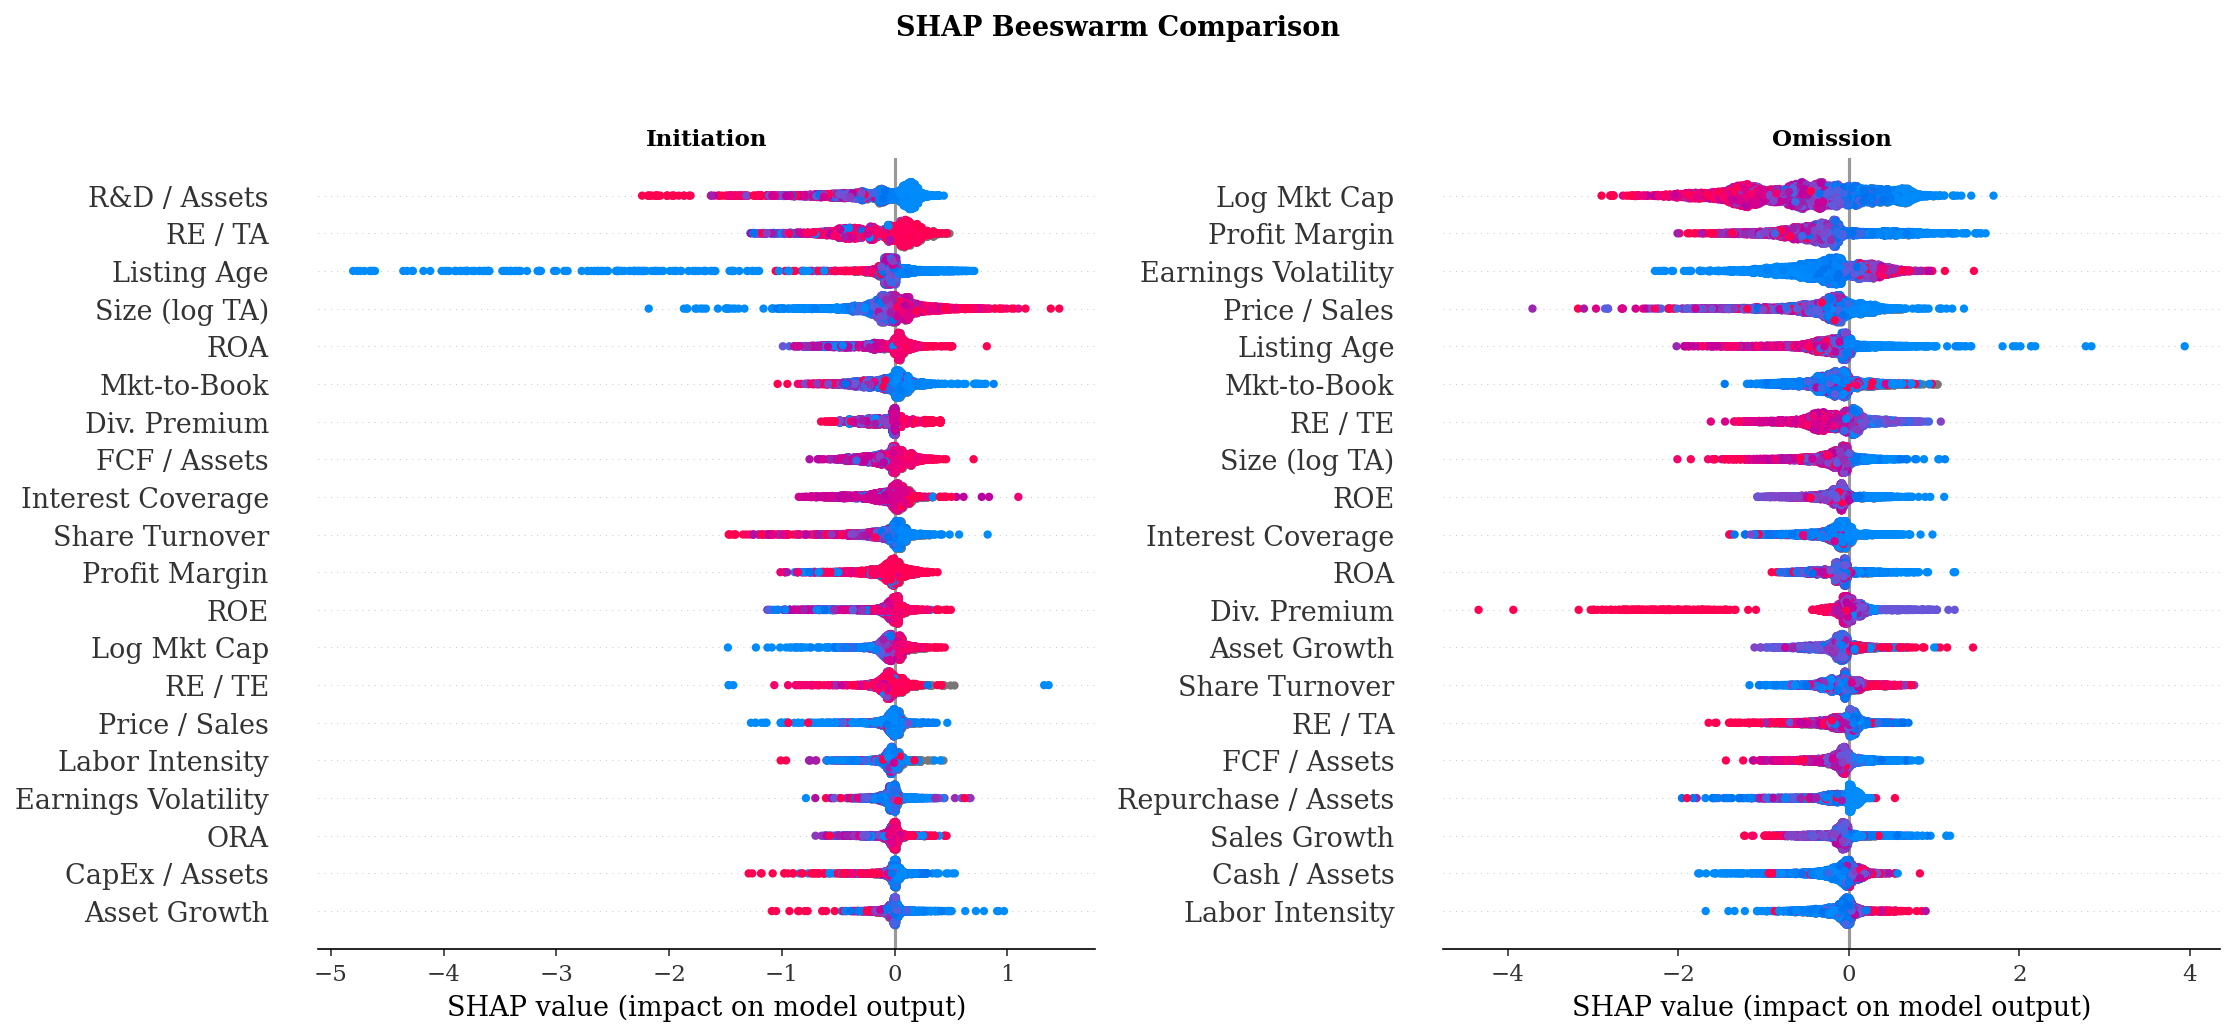

Saved → results/figures/shap_beeswarm_initiation_omission.png


In [9]:
def _sample_shap_for_task(task, max_n=5000):
    task_df = local_shap_df[local_shap_df['task'].eq(task)]
    if len(task_df) > max_n:
        task_df = task_df.sample(n=max_n, random_state=SEED)
    shap_vals = task_df[[f'shap_{feature}' for feature in FEATURES]].to_numpy()
    feature_vals = task_df[[f'value_{feature}' for feature in FEATURES]].copy()
    feature_vals.columns = [SHORT_LABELS.get(feature, feature) for feature in FEATURES]
    return shap_vals, feature_vals

fig, axes = plt.subplots(1, 2, figsize=(15, 7), dpi=150)
for ax, task in zip(axes, ('initiation', 'omission')):
    shap_vals, feature_vals = _sample_shap_for_task(task)
    plt.sca(ax)
    shap.summary_plot(
        shap_vals,
        feature_vals,
        max_display=20,
        show=False,
        plot_size=None,
        color_bar=False,
    )
    ax.set_title(task.capitalize(), fontsize=11, fontweight='bold')

fig.suptitle('SHAP Beeswarm Comparison', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGS_DIR / 'shap_beeswarm_initiation_omission.png', bbox_inches='tight')
fig.savefig(FIGS_DIR / 'shap_beeswarm_initiation_omission.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/figures/shap_beeswarm_initiation_omission.png")


## §9 — Top 5 SHAP predictors by time period

For each time period the five predictors with the highest mean absolute XGBoost SHAP values are reported. Within each period, contributions are averaged across all fold years in that window, ranked, and expressed as a percentage of the total mean absolute SHAP sum. The cumulative share column shows how much of the total predictive weight is concentrated in the top predictors. Results are reported separately for the initiation and omission tasks. Periods: 2003\2009, 2010\2019, 2020\2025, and Overall (all folds).

In [19]:
PERIODS = {
    '2003–2009': range(2003, 2010),
    '2010–2019': range(2010, 2020),
    '2020–2025': range(2020, 2026),
    'Overall':   range(2000, 2026),
}
TOP_N = 5

top5_rows = []

for task in ('initiation', 'omission'):
    task_label = 'Initiation' if task == 'initiation' else 'Omission'
    for period_label, period_years in PERIODS.items():
        fold_arrays = [
            shap_by_fold[task][yr]
            for yr in period_years
            if yr in shap_by_fold[task]
        ]
        if not fold_arrays:
            continue

        period_mean = np.stack(fold_arrays).mean(axis=0)  # (34,)
        sv_ser = pd.Series(period_mean, index=FEATURES)
        total_shap = sv_ser.sum()
        top_feats = sv_ser.nlargest(TOP_N)

        cumulative = 0.0
        for rank, (feat, val) in enumerate(top_feats.items(), 1):
            share = val / total_shap * 100 if total_shap > 0 else np.nan
            cumulative += share
            top5_rows.append({
                'Task':           task_label,
                'Period':         period_label,
                'Rank':           rank,
                'Feature':        SHORT_LABELS.get(feat, feat),
                'Mean |SHAP|':    round(val, 5),
                'SHAP share (%)': round(share, 2),
                'Cumulative (%)': round(cumulative, 2),
            })

top5_df = pd.DataFrame(top5_rows)
display(top5_df)

# Save CSV
top5_path = TABLES_DIR / 'top5_shap_by_period.csv'
top5_df.to_csv(top5_path, index=False)

# Save LaTeX
latex_top5 = top5_df.to_latex(
    index=False,
    caption='Top 5 XGBoost SHAP predictors by time period. '
            'Values are mean absolute SHAP averaged across fold years within each period.',
    label='tab:top5_shap_by_period',
    column_format='llrp{3.2cm}rrr',
    escape=True,
)
latex_path = TABLES_DIR / 'top5_shap_by_period.tex'
with open(latex_path, 'w') as fh:
    fh.write(latex_top5)

print(f"Saved → {top5_path}")
print(f"Saved → {latex_path}")

,Task,Period,Rank,Feature,Mean |SHAP|,SHAP share (%),Cumulative (%)
0,Initiation,2003–2009,1,RE / TA,0.32437,11.53,11.530000
1,Initiation,2003–2009,2,R&D / Assets,0.24435,8.69,20.219999
2,Initiation,2003–2009,3,FCF / Assets,0.19171,6.81,27.030001
3,Initiation,2003–2009,4,Size (log TA),0.18601,6.61,33.639999
4,Initiation,2003–2009,5,Listing Age,0.16976,6.03,39.680000
5,Initiation,2010–2019,1,R&D / Assets,0.26428,9.13,9.130000
6,Initiation,2010–2019,2,Listing Age,0.19568,6.76,15.890000
7,Initiation,2010–2019,3,Size (log TA),0.19173,6.62,22.510000
8,Initiation,2010–2019,4,ROA,0.17428,6.02,28.530001
9,Initiation,2010–2019,5,RE / TA,0.16253,5.61,34.139999


Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/top5_shap_by_period.csv
Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/top5_shap_by_period.tex


## §10 — Time-varying SHAP table

Identifies the single most influential predictor in each test fold (Table 5.5). Provides a year-by-year narrative of which economic signal drives dividend prediction, complementing the block-level view in §9.

In [11]:
winning_variable_rows = []

for task in ('initiation', 'omission'):
    for fold_year in sorted(shap_by_fold[task].keys()):
        mean_abs = pd.Series(shap_by_fold[task][fold_year], index=FEATURES)

        winning_feature = mean_abs.idxmax()
        winning_value = mean_abs.loc[winning_feature]
        total_shap = mean_abs.sum()

        winning_variable_rows.append({
            'task': task,
            'year': fold_year,
            'winning_feature': winning_feature,
            'winning_variable': SHORT_LABELS.get(winning_feature, winning_feature),
            'theory_block': FEAT_TO_BLOCK.get(winning_feature, '').replace('\n', ' '),
            'mean_abs_shap': winning_value,
            'share_of_total_shap': winning_value / total_shap if total_shap > 0 else np.nan,
        })

winning_variable_by_year = pd.DataFrame(winning_variable_rows)

# Display clean table
display(
    winning_variable_by_year
    .assign(
        mean_abs_shap=lambda d: d['mean_abs_shap'].round(4),
        share_of_total_shap=lambda d: (d['share_of_total_shap'] * 100).round(2),
    )
)

# Save CSV
winning_variable_path = TABLES_DIR / 'winning_variable_by_year.csv'
winning_variable_by_year.to_csv(winning_variable_path, index=False)

# Save LaTeX table
latex_path = TABLES_DIR / 'winning_variable_by_year.tex'
latex_table = (
    winning_variable_by_year
    .assign(
        mean_abs_shap=lambda d: d['mean_abs_shap'].round(4),
        share_of_total_shap=lambda d: (d['share_of_total_shap'] * 100).round(2),
    )
    .rename(columns={
        'task': 'Task',
        'year': 'Year',
        'winning_variable': 'Winning variable',
        'theory_block': 'Theory block',
        'mean_abs_shap': 'Mean |SHAP|',
        'share_of_total_shap': 'Share of total SHAP (%)',
    })
    [['Task', 'Year', 'Winning variable', 'Theory block', 'Mean |SHAP|', 'Share of total SHAP (%)']]
    .to_latex(
        index=False,
        caption='Year-by-year winning variables based on fold-level mean absolute SHAP values.',
        label='tab:winning_variable_by_year',
        column_format='llp{3.2cm}p{4.2cm}rr',
        escape=True,
    )
)

with open(latex_path, 'w') as fh:
    fh.write(latex_table)

print(f"Saved → {winning_variable_path}")
print(f"Saved → {latex_path}")

,task,year,winning_feature,winning_variable,theory_block,mean_abs_shap,share_of_total_shap
0,initiation,2000,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.3004,10.950000
1,initiation,2001,DIVPREM_lag1,Div. Premium,Catering Premium (Behavioral),0.2509,11.270000
2,initiation,2002,Size_lag1,Size (log TA),Life-Cycle & Maturity,0.4150,6.370000
3,initiation,2003,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.4614,17.680000
4,initiation,2004,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.4556,17.020000
5,initiation,2005,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.3123,11.460000
6,initiation,2006,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.2766,12.160000
7,initiation,2007,RE_TA_lag1,RE / TA,Life-Cycle & Maturity,0.2818,13.110000
8,initiation,2008,Size_lag1,Size (log TA),Life-Cycle & Maturity,0.2642,10.460000
9,initiation,2009,RD_assets_lag1,R&D / Assets,Growth Options & Investment,0.3673,7.760000


Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/winning_variable_by_year.csv
Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/winning_variable_by_year.tex


## §11 — Investor screening

Table 5.6 and Figure 5.3. At the start of each fiscal year, all firms in the risk set are ranked by predicted event probability. Screening at top-5%, top-10%, and top-20% review budgets measures the practical value of the model: how many actual initiators or omitters would an investor catch by reviewing only the highest-scored firms?

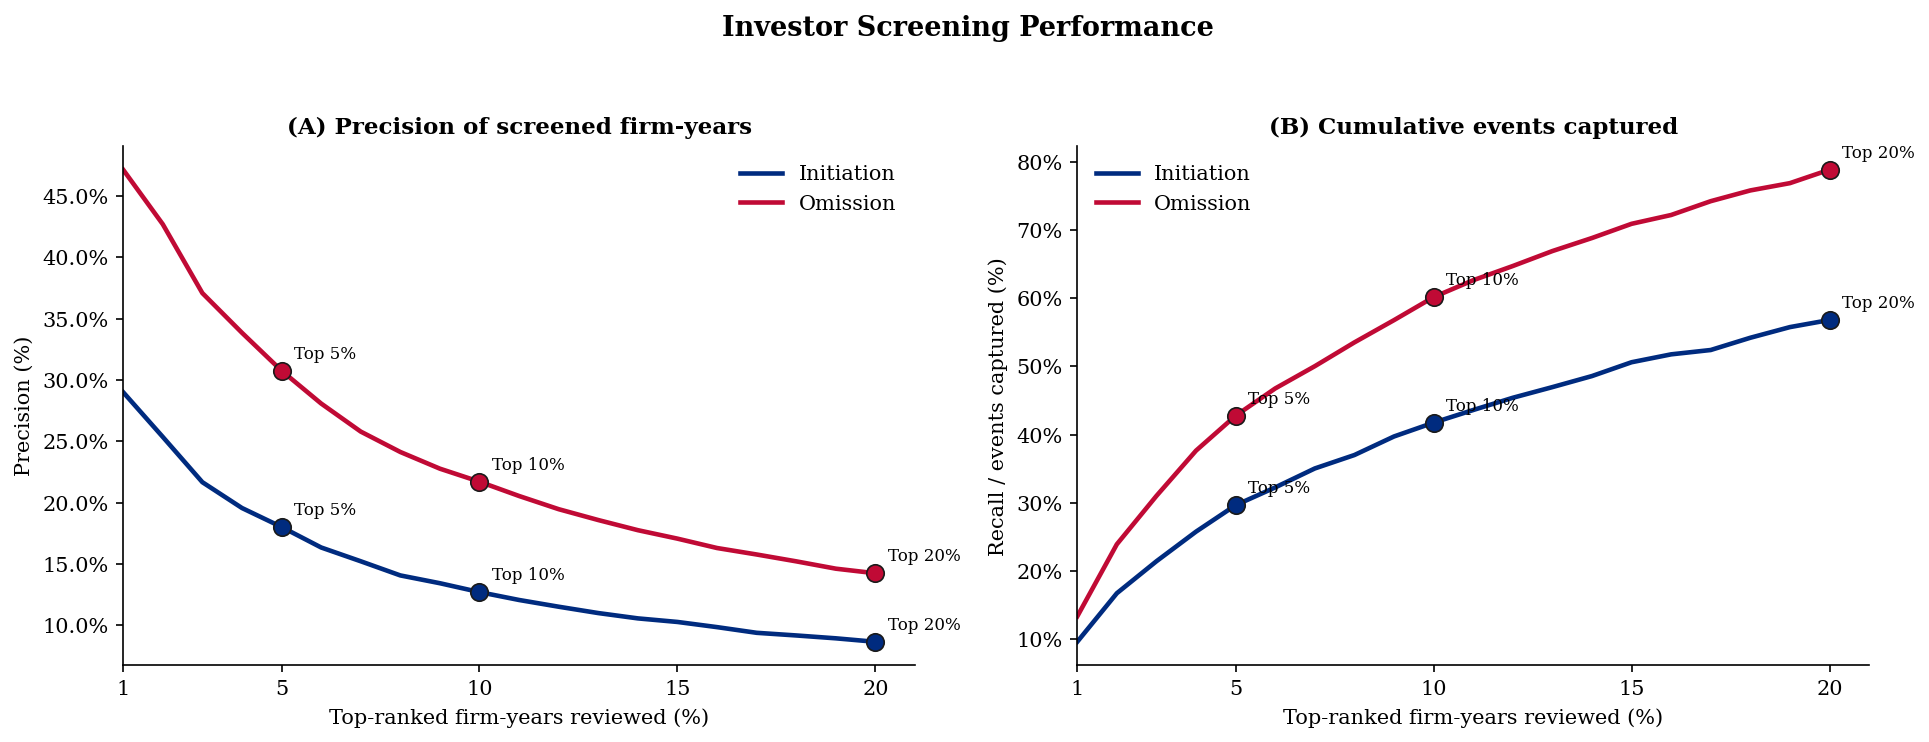

Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/investor_screening_top_percent.csv
Saved → results/figures/investor_screening_fold_level_curve.png


In [12]:
SCREEN_GRID = np.arange(0.01, 0.201, 0.01)
TABLE_PCTS = [0.05, 0.10, 0.20]

screen_rows = []
for task in ('initiation', 'omission'):
    task_df = local_shap_df[local_shap_df['task'].eq(task)]
    total_events = int(task_df['target_event'].sum())
    total_obs = len(task_df)
    base_rate = total_events / total_obs

    for pct in SCREEN_GRID:
        screened = 0
        captured = 0

        for _, fold_df in task_df.groupby('fold'):
            n_screen = max(1, int(np.ceil(len(fold_df) * pct)))
            chosen = fold_df.nlargest(n_screen, 'pred_prob')
            screened += len(chosen)
            captured += int(chosen['target_event'].sum())

        precision = captured / screened
        recall = captured / total_events

        screen_rows.append({
            'task': task,
            'top_percent': pct,
            'screened_firm_years': screened,
            'true_events_captured': captured,
            'total_events': total_events,
            'precision': precision,
            'recall': recall,
            'base_rate': base_rate,
            'lift_vs_base_rate': precision / base_rate,
        })

screen_curve = pd.DataFrame(screen_rows)
investor_screening = screen_curve[screen_curve['top_percent'].isin(TABLE_PCTS)].copy()
investor_screening_path = TABLES_DIR / 'investor_screening_top_percent.csv'
investor_screening.to_csv(investor_screening_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150, sharex=True)
for task, color in [('initiation', UU_BLUE), ('omission', UU_RED)]:
    d = screen_curve[screen_curve['task'].eq(task)]
    x = d['top_percent'] * 100

    axes[0].plot(x, d['precision'] * 100, color=color, lw=2.2, label=task.capitalize())
    axes[1].plot(x, d['recall'] * 100, color=color, lw=2.2, label=task.capitalize())

    for pct in TABLE_PCTS:
        point = d[np.isclose(d['top_percent'], pct)].iloc[0]
        for ax, y_col in [(axes[0], 'precision'), (axes[1], 'recall')]:
            ax.scatter(
                pct * 100,
                point[y_col] * 100,
                s=70,
                color=color,
                edgecolor=UU_DARK,
                linewidth=0.8,
                zorder=5,
            )
            ax.annotate(
                f'Top {int(pct * 100)}%',
                xy=(pct * 100, point[y_col] * 100),
                xytext=(6, 6),
                textcoords='offset points',
                fontsize=8,
            )

axes[0].set_title('(A) Precision of screened firm-years', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Cumulative events captured', fontsize=11, fontweight='bold')
for ax in axes:
    ax.set_xlabel('Top-ranked firm-years reviewed (%)')
    ax.set_xlim(1, 21)
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(frameon=False)
axes[0].set_ylabel('Precision (%)')
axes[1].set_ylabel('Recall / events captured (%)')

fig.suptitle('Investor Screening Performance', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGS_DIR / 'investor_screening_fold_level_curve.png', bbox_inches='tight')
fig.savefig(FIGS_DIR / 'investor_screening_fold_level_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved → {investor_screening_path}')
print('Saved → results/figures/investor_screening_fold_level_curve.png')


## §12 — Single-year screening example

FY2024 watchlist illustration (Appendix A.2). Demonstrates the screening workflow for a single recent year, showing how many events fall inside each review budget.

In [13]:
EXAMPLE_YEAR = 2024
SCREEN_PCTS = [0.05, 0.10, 0.20]

rows = []
for task in ('initiation', 'omission'):
    year_df = (
        local_shap_df[
            local_shap_df['task'].eq(task)
            & local_shap_df['fold'].eq(EXAMPLE_YEAR)
        ]
        .copy()
        .sort_values('pred_prob', ascending=False)
    )

    if year_df.empty:
        raise ValueError(f'No rows found for task={task}, year={EXAMPLE_YEAR}.')

    total_firms = len(year_df)
    total_events = int(year_df['target_event'].sum())
    base_rate = total_events / total_firms

    for pct in SCREEN_PCTS:
        n_screen = max(1, int(np.ceil(total_firms * pct)))
        screened = year_df.head(n_screen)
        captured = int(screened['target_event'].sum())

        rows.append({
            'task': task,
            'year': EXAMPLE_YEAR,
            'screen': f'Top {int(pct * 100)}%',
            'universe_firms': total_firms,
            'screened_firms': n_screen,
            'actual_events_in_year': total_events,
            'events_captured': captured,
            'events_missed': total_events - captured,
            'precision': captured / n_screen,
            'recall': captured / total_events if total_events else np.nan,
            'base_rate': base_rate,
            'lift': (captured / n_screen) / base_rate,
        })

year_screening_summary = pd.DataFrame(rows)
display(
    year_screening_summary.assign(
        precision=lambda d: (d['precision'] * 100).round(2),
        recall=lambda d: (d['recall'] * 100).round(2),
        base_rate=lambda d: (d['base_rate'] * 100).round(2),
        lift=lambda d: d['lift'].round(2),
    )
)

year_screening_summary_path = TABLES_DIR / f'investor_screening_single_year_{EXAMPLE_YEAR}.csv'
year_screening_summary.to_csv(year_screening_summary_path, index=False)
print(f'Saved → {year_screening_summary_path}')


,task,year,screen,universe_firms,screened_firms,actual_events_in_year,events_captured,events_missed,precision,recall,base_rate,lift
0,initiation,2024,Top 5%,1495,75,29,7,22,9.33,24.14,1.94,4.81
1,initiation,2024,Top 10%,1495,150,29,10,19,6.67,34.48,1.94,3.44
2,initiation,2024,Top 20%,1495,299,29,15,14,5.02,51.72,1.94,2.59
3,omission,2024,Top 5%,1768,89,42,18,24,20.22,42.86,2.38,8.51
4,omission,2024,Top 10%,1768,177,42,25,17,14.12,59.52,2.38,5.95
5,omission,2024,Top 20%,1768,354,42,36,6,10.17,85.71,2.38,4.28


Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/investor_screening_single_year_2024.csv


## §13 — Local SHAP plotting helpers

Reusable functions for case-study figures. All local explanations use saved out-of-sample XGBoost SHAP values from the walk-forward loop — no model is retrained for individual explanations.

In [14]:
def _local_case_title(row, task, status_label):
    firm = row.get('CompanyName', '')
    ticker = row.get('Ticker', '')
    firm_label = f"{firm} ({ticker})" if pd.notna(ticker) and str(ticker) else str(firm)
    return (
        f"{firm_label} — FY{int(row['FiscalYear'])}\n"
        f"{status_label} | target={int(row['target_event'])} | P({task})={row['pred_prob']:.3f}"
    )


def get_local_shap_case(task, firm_id=None, fiscal_year=None, ticker=None, company_contains=None, highest_prob=True):
    """Return one saved out-of-sample XGBoost SHAP case from local_shap_df."""
    case = local_shap_df[local_shap_df['task'].eq(task)].copy()
    if firm_id is not None:
        case = case[case['FirmID'].eq(firm_id)]
    if fiscal_year is not None:
        case = case[case['FiscalYear'].eq(fiscal_year)]
    if ticker is not None and 'Ticker' in case.columns:
        case = case[case['Ticker'].astype(str).str.upper().eq(str(ticker).upper())]
    if company_contains is not None and 'CompanyName' in case.columns:
        case = case[case['CompanyName'].astype(str).str.contains(company_contains, case=False, na=False)]
    if case.empty:
        raise ValueError('No saved local SHAP case matches the requested filters.')
    return case.sort_values('pred_prob', ascending=not highest_prob).iloc[0]


def plot_local_shap_row(ax, row, task, status_label, n_feats=15):
    """Stable horizontal signed-contribution plot for one saved local SHAP row."""
    shap_ser = pd.Series({feature: row[f'shap_{feature}'] for feature in FEATURES})
    sv_top = shap_ser[shap_ser.abs().nlargest(n_feats).index].sort_values()

    vals = sv_top.values
    labels = [SHORT_LABELS.get(feature, feature) for feature in sv_top.index]
    colors = [UU_GREEN if value >= 0 else UU_RED for value in vals]

    y_pos = np.arange(len(vals))
    ax.barh(y_pos, vals, color=colors, edgecolor='none', height=0.72)
    ax.axvline(0, color=UU_DARK, lw=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(f'SHAP value on model-score scale (→ increases {task} probability)', fontsize=10)
    ax.set_title(_local_case_title(row, task, status_label), fontsize=10.5, fontweight='bold', pad=6)

    for i, value in enumerate(vals):
        ha = 'left' if value >= 0 else 'right'
        offset = 0.001 if value >= 0 else -0.001
        ax.text(value + offset, i, f'{value:+.3f}', va='center', ha=ha, fontsize=7.5, color=UU_DARK)


def save_local_contribution_figure(row, task, status_label, filename_stem, n_feats=15):
    """Save one waterfall-style signed-contribution chart as PNG."""
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    plot_local_shap_row(ax, row, task, status_label, n_feats=n_feats)
    fig.suptitle('Local SHAP Contribution Chart\n(values are on the model-score scale)', fontsize=12, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    png_path = FIGS_DIR / f'{filename_stem}.png'
    fig.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return png_path


## §14 — Initiation case studies: Meta and Starbucks

Generates the named initiation cases used in the thesis discussion (§5.6). Meta FY2024 is a false negative where growth-option signals (R&D, Market-to-Book) suppress the initiation score despite life-cycle maturity. Starbucks FY2010 is a true positive where size and free cash flow dominate.

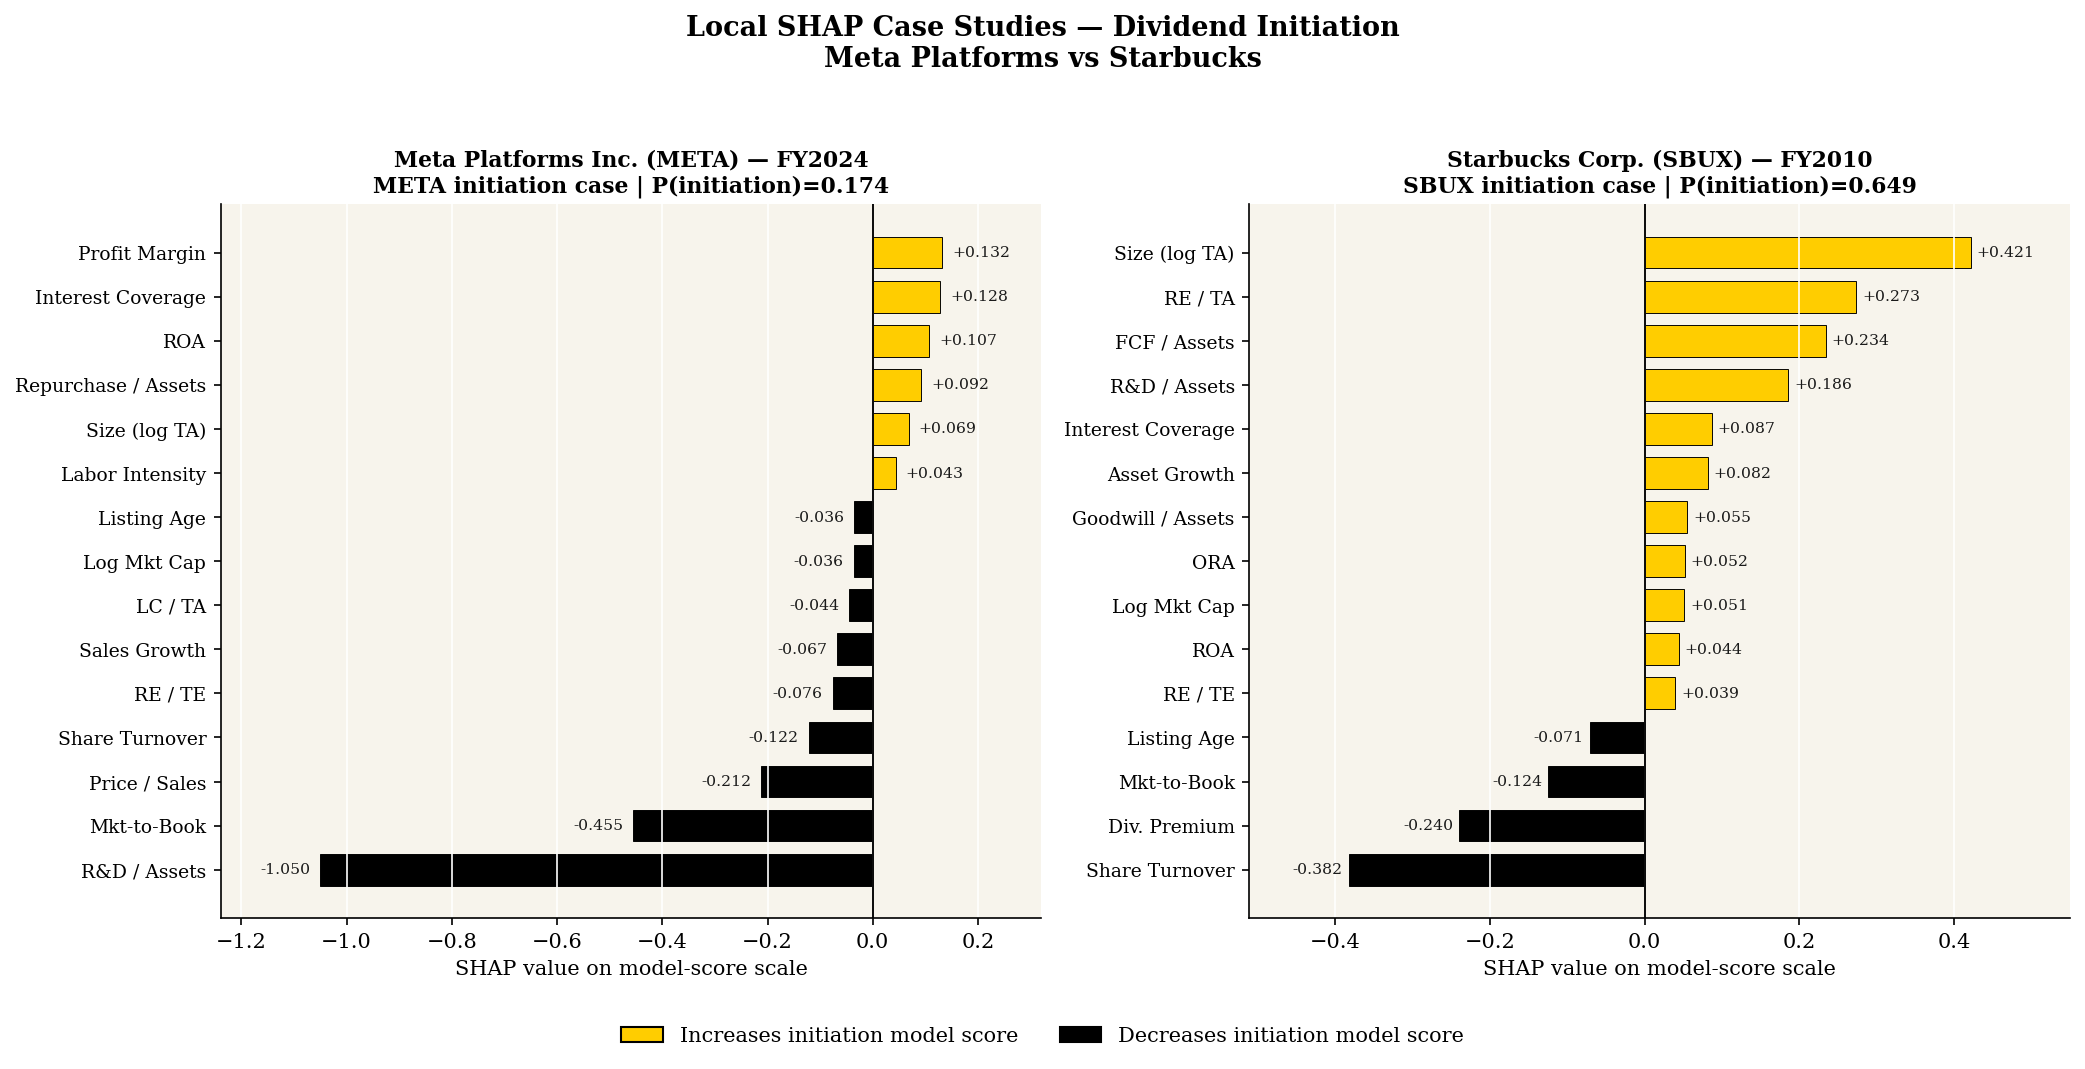

Saved → results/figures/shap_case_studies_initiation.png
Saved → results/figures/shap_waterfall_initiation_{case_left,case_right}.png


In [15]:
# ── Utrecht colours ────────────────────────────────────────────────────────
UU_YELLOW = '#FFCD00'
UU_BLACK  = '#000000'
UU_DARK   = '#1A1A1A'
UU_LIGHT  = '#F7F4EC'

POS_COLOR = UU_YELLOW   # positive SHAP: increases score
NEG_COLOR = UU_BLACK    # negative SHAP: decreases score


def plot_local_shap_row(ax, row, task, status_label, n_feats=15):
    """Local SHAP contribution plot — Utrecht yellow/black style."""
    shap_ser = pd.Series({
        feature: row[f'shap_{feature}']
        for feature in FEATURES
        if f'shap_{feature}' in row.index
    })
    top_idx = shap_ser.abs().nlargest(n_feats).index
    sv_top  = shap_ser[top_idx].sort_values()

    vals   = sv_top.values
    labels = [SHORT_LABELS.get(f, f) for f in sv_top.index]
    colors = [POS_COLOR if v >= 0 else NEG_COLOR for v in vals]
    y_pos  = np.arange(len(vals))

    ax.set_facecolor(UU_LIGHT)
    ax.barh(y_pos, vals, color=colors, edgecolor=UU_BLACK,
            linewidth=0.45, height=0.72)
    ax.axvline(0, color=UU_BLACK, lw=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('SHAP value on model-score scale', fontsize=10)

    firm   = row.get('display_name', row.get('CompanyName', ''))
    ticker = row.get('Ticker', '')
    firm_label = f"{firm} ({ticker})" if pd.notna(ticker) and str(ticker) else str(firm)
    ax.set_title(
        f"{firm_label} — FY{int(row['FiscalYear'])}\n"
        f"{status_label} | P({task})={row['pred_prob']:.3f}",
        fontsize=10.5, fontweight='bold', pad=6,
    )

    max_abs = max(abs(vals).max(), 0.01)
    for i, value in enumerate(vals):
        ha, offset = ('left', 0.018 * max_abs) if value >= 0 else ('right', -0.018 * max_abs)
        ax.text(value + offset, i, f'{value:+.3f}',
                va='center', ha=ha, fontsize=7.5, color=UU_DARK)

    ax.grid(axis='x', color='white', linewidth=0.8)
    ax.grid(axis='y', visible=False)

    # Expand x-axis to prevent annotation clipping on extreme bars
    xl = ax.get_xlim()
    pad = 0.10 * (xl[1] - xl[0])
    ax.set_xlim(xl[0] - pad, xl[1] + pad)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color(UU_BLACK)
    ax.spines['bottom'].set_color(UU_BLACK)


def save_local_contribution_figure(row, task, status_label, filename_stem, n_feats=15):
    """Save one Utrecht-style local SHAP chart as PNG."""
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    fig.patch.set_facecolor('white')
    plot_local_shap_row(ax, row, task, status_label, n_feats=n_feats)

    pos_patch = mpatches.Patch(facecolor=POS_COLOR, edgecolor=UU_BLACK,
                               label=f'Increases {task} model score')
    neg_patch = mpatches.Patch(facecolor=NEG_COLOR, edgecolor=UU_BLACK,
                               label=f'Decreases {task} model score')
    fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
               ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle('Local SHAP Contribution Chart', fontsize=12, fontweight='bold')
    fig.tight_layout(rect=[0, 0.04, 1, 0.93])

    png_path = FIGS_DIR / f'{filename_stem}.png'
    fig.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return png_path


# ── Select Meta and Starbucks cases ────────────────────────────────────────
INIT_CASES = [
    {
        'key': 'case_left',
        'label': 'META',
        'firm_id': 170617,
        'fiscal_year': 2024,
        'display_name': 'Meta Platforms Inc.',
    },
    {
        'key': 'case_right',
        'label': 'SBUX',
        'firm_id': 25434,
        'fiscal_year': 2010,
        'display_name': 'Starbucks Corp.',
    },
]

selected_init_cases = []
for spec in INIT_CASES:
    row = get_local_shap_case(
        'initiation',
        firm_id=spec['firm_id'],
        fiscal_year=spec['fiscal_year'],
        highest_prob=True,
    ).copy()
    row['case_label'] = spec['label']
    row['display_name'] = spec['display_name']
    selected_init_cases.append(row)

# ── Combined figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(selected_init_cases),
                         figsize=(7 * len(selected_init_cases), 7), dpi=150)
fig.patch.set_facecolor('white')
if len(selected_init_cases) == 1:
    axes = [axes]

for ax, row, spec in zip(axes, selected_init_cases, INIT_CASES):
    status = f"{spec['label']} initiation case"
    plot_local_shap_row(ax, row, 'initiation', status)

pos_patch = mpatches.Patch(facecolor=POS_COLOR, edgecolor=UU_BLACK,
                           label='Increases initiation model score')
neg_patch = mpatches.Patch(facecolor=NEG_COLOR, edgecolor=UU_BLACK,
                           label='Decreases initiation model score')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
           ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Local SHAP Case Studies — Dividend Initiation\n'
             'Meta Platforms vs Starbucks',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(FIGS_DIR / 'shap_case_studies_initiation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Separate waterfall figures ─────────────────────────────────────────────
for row, spec in zip(selected_init_cases, INIT_CASES):
    save_local_contribution_figure(
        row, 'initiation',
        f"{spec['label']} initiation case",
        f"shap_waterfall_initiation_{spec['key']}",
    )

print("Saved → results/figures/shap_case_studies_initiation.png")
print("Saved → results/figures/shap_waterfall_initiation_{case_left,case_right}.png")

## §15 — Appendix B: Alphabet case

Alphabet FY2024 (Appendix B.1). Same false-negative mechanism as Meta —
high R\&D intensity and Market-to-Book override life-cycle maturity signals.
Shown alongside Meta for direct comparison.

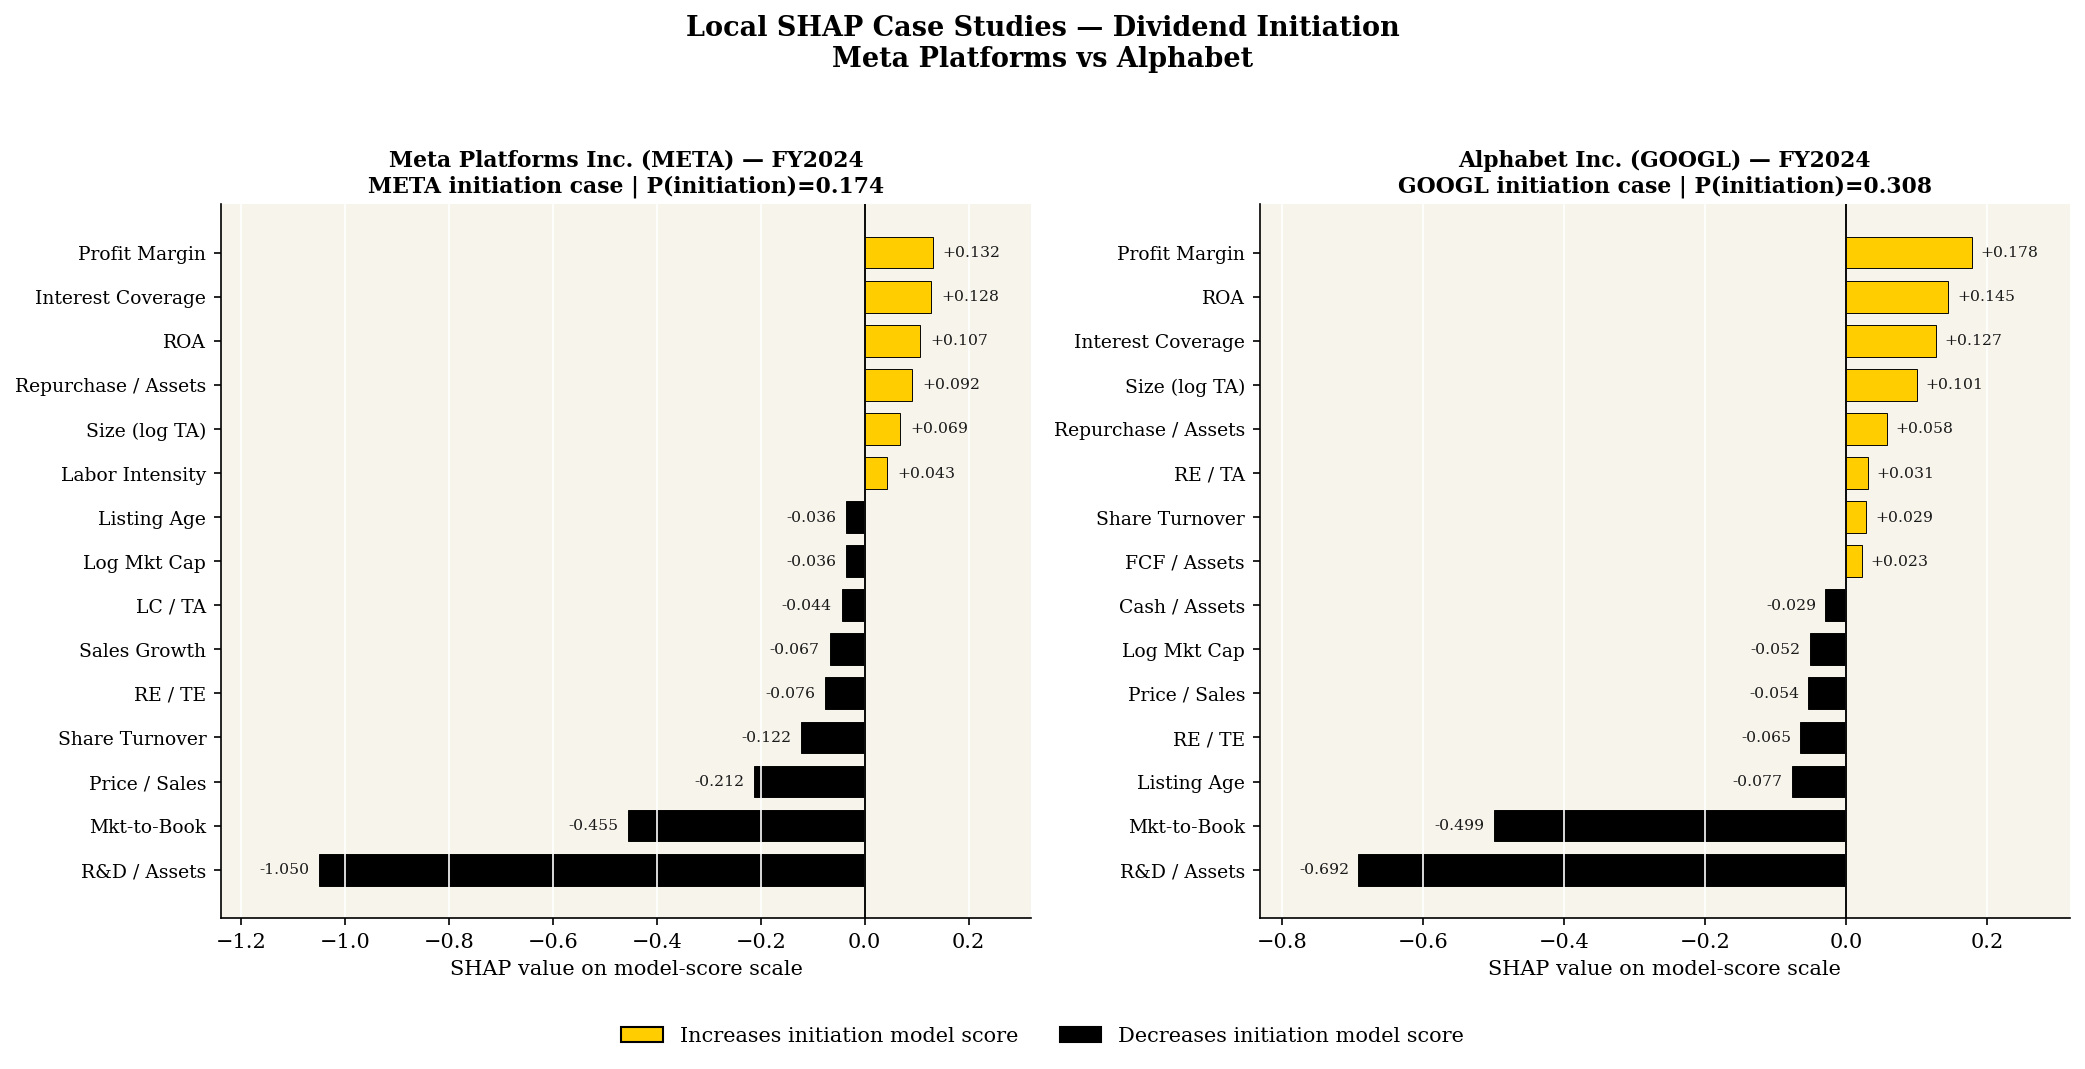

Alphabet case: {'FirmID': np.int64(160329), 'FiscalYear': np.int64(2024), 'Ticker': 'GOOGL', 'CompanyName': 'ALPHABET INC', 'pred_prob': np.float32(0.30782744), 'target_event': np.int64(1)}
Saved → results/figures/shap_case_studies_initiation_meta_alphabet.png
Saved → results/figures/shap_waterfall_initiation_alphabet.png


In [16]:
def get_alphabet_case():
    """Return Alphabet's FY2024 initiation row from saved local SHAP results."""
    for ticker in ['GOOGL', 'GOOG']:
        try:
            return get_local_shap_case(
                'initiation',
                ticker=ticker,
                fiscal_year=2024,
                highest_prob=True,
            ).copy()
        except ValueError:
            pass

    return get_local_shap_case(
        'initiation',
        company_contains='Alphabet',
        fiscal_year=2024,
        highest_prob=True,
    ).copy()


ALPHABET_CASE = get_alphabet_case()

# ── Side-by-side: Meta vs Alphabet (Appendix B.1) ─────────────────────────
meta_row = selected_init_cases[0]  # META from §14 above

APPENDIX_CASES = [
    {'row': meta_row,       'label': 'META',  'display_name': 'Meta Platforms Inc.'},
    {'row': ALPHABET_CASE,  'label': 'GOOGL', 'display_name': 'Alphabet Inc.'},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=150)
fig.patch.set_facecolor('white')

for ax, spec in zip(axes, APPENDIX_CASES):
    spec['row']['display_name'] = spec['display_name']
    plot_local_shap_row(ax, spec['row'], 'initiation',
                        f"{spec['label']} initiation case")

pos_patch = mpatches.Patch(facecolor=POS_COLOR, edgecolor=UU_BLACK,
                           label='Increases initiation model score')
neg_patch = mpatches.Patch(facecolor=NEG_COLOR, edgecolor=UU_BLACK,
                           label='Decreases initiation model score')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
           ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Local SHAP Case Studies — Dividend Initiation\n'
             'Meta Platforms vs Alphabet',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(FIGS_DIR / 'shap_case_studies_initiation_meta_alphabet.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Standalone Alphabet waterfall ──────────────────────────────────────────
save_local_contribution_figure(
    ALPHABET_CASE, 'initiation',
    'Alphabet initiation case',
    'shap_waterfall_initiation_alphabet',
)

cols = ['FirmID', 'FiscalYear', 'Ticker', 'CompanyName', 'pred_prob', 'target_event']
available_cols = [c for c in cols if c in ALPHABET_CASE.index]
print('Alphabet case:', dict(ALPHABET_CASE[available_cols]))
print("Saved → results/figures/shap_case_studies_initiation_meta_alphabet.png")
print("Saved → results/figures/shap_waterfall_initiation_alphabet.png")

## §16 — Intel omission case

Intel FY2025 omission case study (§5.6). A true positive where operational distress signals (collapsing margins, earnings volatility) overcome the negative contribution from Intel's historically large market capitalisation.

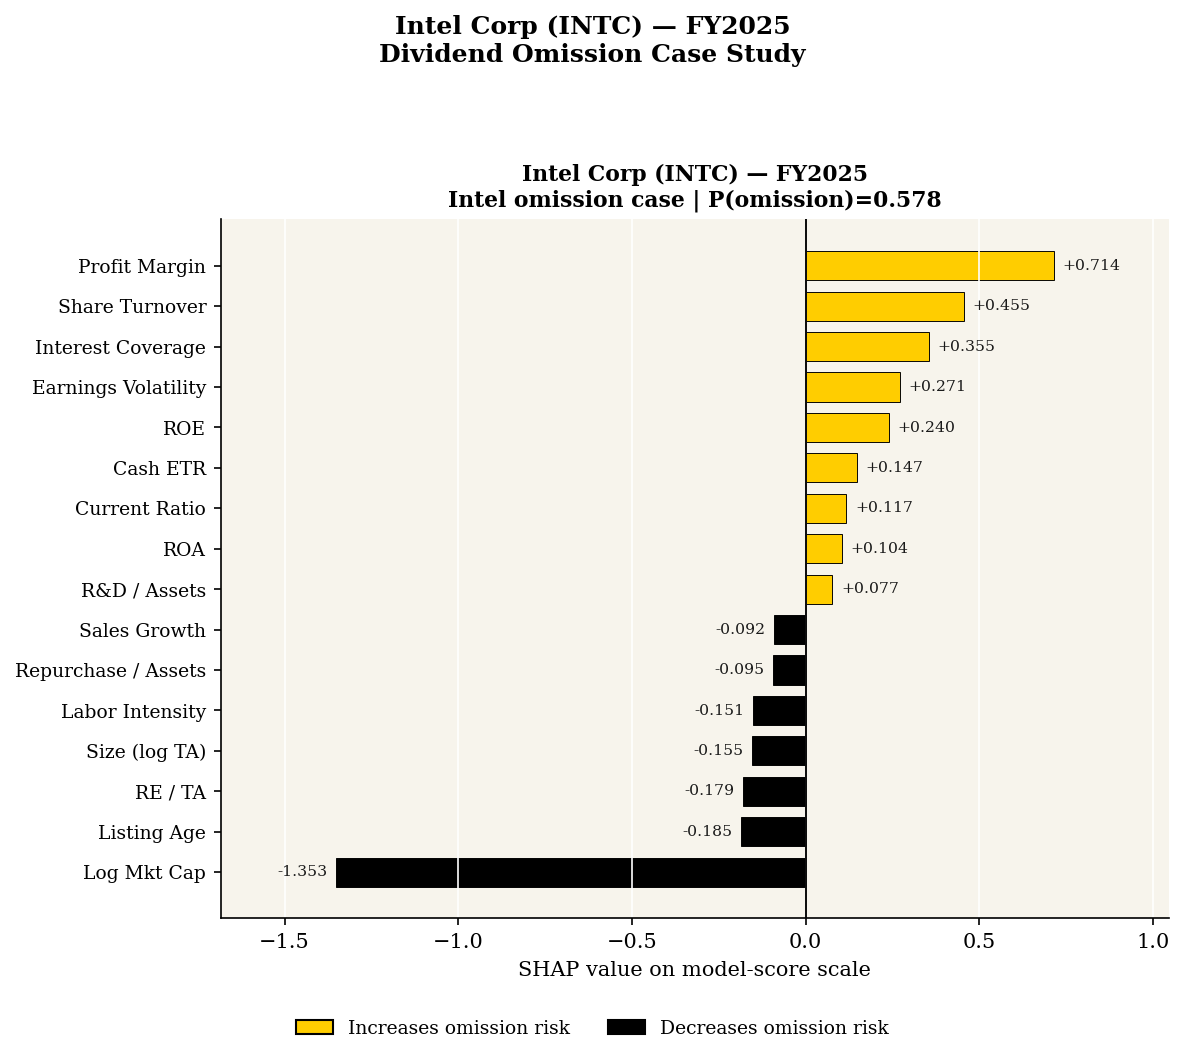

,CompanyName,Ticker,FiscalYear,pred_prob,target_event,rank_in_year,universe_firms,rank_percentile,actual_events_in_year
0,INTEL CORP,INTC,2025,0.5775,1,210,1582,13.27,41


Saved → results/figures/shap_case_study_omission_intel.png
Saved → results/figures/shap_waterfall_omission_intel.png
Saved → /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/intel_omission_case_overview.csv


In [17]:
def get_intel_case():
    """Return Intel's FY2025 omission row from saved local SHAP results."""
    try:
        return get_local_shap_case(
            'omission',
            ticker='INTC',
            fiscal_year=2025,
            highest_prob=True,
        ).copy()
    except ValueError:
        return get_local_shap_case(
            'omission',
            company_contains='Intel',
            fiscal_year=2025,
            highest_prob=True,
        ).copy()


INTEL_CASE = get_intel_case()

intel_fold = local_shap_df[
    local_shap_df['task'].eq('omission')
    & local_shap_df['fold'].eq(int(INTEL_CASE['fold']))
].copy()
intel_rank = int(intel_fold['pred_prob'].rank(method='first', ascending=False).loc[INTEL_CASE.name])
intel_universe = len(intel_fold)
intel_events = int(intel_fold['target_event'].sum())

intel_overview = pd.DataFrame([{
    'CompanyName': INTEL_CASE.get('CompanyName', ''),
    'Ticker': INTEL_CASE.get('Ticker', ''),
    'FiscalYear': int(INTEL_CASE['FiscalYear']),
    'pred_prob': float(INTEL_CASE['pred_prob']),
    'target_event': int(INTEL_CASE['target_event']),
    'rank_in_year': intel_rank,
    'universe_firms': intel_universe,
    'rank_percentile': intel_rank / intel_universe,
    'actual_events_in_year': intel_events,
}])

# ── Inline display ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
fig.patch.set_facecolor('white')
INTEL_CASE['display_name'] = 'Intel Corp'
plot_local_shap_row(ax, INTEL_CASE, 'omission', 'Intel omission case', n_feats=16)

pos_patch = mpatches.Patch(facecolor=POS_COLOR, edgecolor=UU_BLACK,
                           label='Increases omission risk')
neg_patch = mpatches.Patch(facecolor=NEG_COLOR, edgecolor=UU_BLACK,
                           label='Decreases omission risk')
fig.legend(handles=[pos_patch, neg_patch], loc='lower center',
           ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Intel Corp (INTC) — FY2025\nDividend Omission Case Study',
             fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0.04, 1, 0.93])
fig.savefig(FIGS_DIR / 'shap_case_study_omission_intel.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Standalone waterfall (same style, saved separately) ────────────────────
save_local_contribution_figure(
    INTEL_CASE, 'omission',
    'Intel omission case',
    'shap_waterfall_omission_intel',
    n_feats=16,
)

intel_overview_path = TABLES_DIR / 'intel_omission_case_overview.csv'
intel_overview.to_csv(intel_overview_path, index=False)

display(
    intel_overview.assign(
        pred_prob=lambda d: d['pred_prob'].round(4),
        rank_percentile=lambda d: (100 * d['rank_percentile']).round(2),
    )
)
print('Saved → results/figures/shap_case_study_omission_intel.png')
print('Saved → results/figures/shap_waterfall_omission_intel.png')
print(f'Saved → {intel_overview_path}')

## §17 — Run-complete summary

Final checklist of all thesis-facing output files produced by this notebook.

In [18]:
NEW_TABLE_PATHS = [
    TABLES_DIR / 'performance.tex',
    TABLES_DIR / 'performance.csv',
    TABLES_DIR / 'local_shap_values_all_firm_years.csv.gz',
    TABLES_DIR / 'winning_variable_by_year.csv',
    TABLES_DIR / 'winning_variable_by_year.tex',
    TABLES_DIR / 'investor_screening_top_percent.csv',
    TABLES_DIR / 'investor_screening_single_year_2024.csv',
    TABLES_DIR / 'xgb_pr_auc_wilcoxon_tests.csv',
    TABLES_DIR / 'xgb_pr_auc_wilcoxon_tests.tex',
    TABLES_DIR / 'intel_omission_case_overview.csv',
]
NEW_FIGURE_PATHS = [
    FIGS_DIR / 'shap_beeswarm_initiation_omission.png',
    FIGS_DIR / 'shap_block_time_size_adjusted_multivar.png',
    FIGS_DIR / 'investor_screening_fold_level_curve.png',
    FIGS_DIR / 'shap_case_studies_initiation.png',
    FIGS_DIR / 'shap_waterfall_initiation_case_left.png',
    FIGS_DIR / 'shap_waterfall_initiation_case_right.png',
    FIGS_DIR / 'shap_waterfall_initiation_alphabet.png',
    FIGS_DIR / 'shap_waterfall_omission_intel.png',
]

print('RUN COMPLETE')
print('-' * 72)
print(f'Model-fold records       : {len(df_rec):,}')
print(f'local_shap_df rows       : {len(local_shap_df):,}')
print(f'Performance table shape  : {perf_mean.shape}')
print()
print('Saved table paths:')
for path in NEW_TABLE_PATHS:
    print(f'  - {path}')
print()
print('Saved figure paths:')
for path in NEW_FIGURE_PATHS:
    print(f'  - {path}')


RUN COMPLETE
------------------------------------------------------------------------
Model-fold records       : 312
local_shap_df rows       : 105,942
Performance table shape  : (12, 4)

Saved table paths:
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/performance.tex
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/performance.csv
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/local_shap_values_all_firm_years.csv.gz
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/winning_variable_by_year.csv
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/winning_variable_by_year.tex
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/investor_screening_top_percent.csv
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/investor_screening_single_year_2024.csv
  - /Users/matyaslezatka/Documents/Thesis/Submission/results/tables/xgb_pr_auc_wilcoxon_tests.csv
  - /Users/mat